In [ ]:
from sklearn.neighbors import kneighbors_graph
import numpy as np

In [ ]:
def get_neighbor(idx, connectivity, points):
    neibor_idx = np.arange(len(points))[connectivity[idx]]
    return neibor_idx

In [ ]:
X = [[0], [3], [1.5], [-0.5]]
X = np.array(X)
# X=np.random.random((200,60))

A = kneighbors_graph(X, 2, mode="connectivity", include_self=False).toarray().astype(bool)
get_neighbor(2, A, X)

array([0, 1])

In [ ]:
x = np.array([[2, 0, 1], [3, 1, 1], [4, 2, 2], [5, 3, 2]], dtype="f8")
x = x - np.mean(x, axis=0)
print(x)

[[-1.5 -1.5 -0.5]
 [-0.5 -0.5 -0.5]
 [ 0.5  0.5  0.5]
 [ 1.5  1.5  0.5]]


In [ ]:
u, s, vt = np.linalg.svd(x)
# 因为s的最后一个特征值接近0，所以这里取两个特征值，
# 因此取vt的前两列，那么x被降维成：
x_ = x @ (vt[:2].T)
print(x_)

[[-2.17682365 -0.10695241]
 [-0.81790909  0.28464843]
 [ 0.81790909 -0.28464843]
 [ 2.17682365  0.10695241]]


In [5]:
print(vt.T)

[[ 6.79457280e-01  1.95800420e-01  7.07106781e-01]
 [ 6.79457280e-01  1.95800420e-01 -7.07106781e-01]
 [ 2.76903610e-01 -9.60897700e-01 -8.74247957e-19]]


In [ ]:
# 重构
x_ @ vt[:2]

array([[-1.5, -1.5, -0.5],
       [-0.5, -0.5, -0.5],
       [ 0.5,  0.5,  0.5],
       [ 1.5,  1.5,  0.5]])

In [ ]:
x = np.array([[1.0, 1.0, 0.0], [1.0, 0.9, 0.0], [1.0, 1.1, 0.0]], dtype="f8")
X = x.T @ x
eigvalues, eigvectors = np.linalg.eigh(X)
print(eigvalues)
print(eigvectors)

[0.         0.00998333 6.01001667]
[[ 0.         -0.70828431  0.70592729]
 [ 0.          0.70592729  0.70828431]
 [ 1.          0.          0.        ]]


In [ ]:
x = np.array([[1, 2, 3], [2, 3, 4]], dtype="f8")
norm_x = np.linalg.norm(x, axis=1, keepdims=True)
print(x / norm_x)
print(np.linalg.norm(x / norm_x, axis=1, keepdims=True))

[[0.26726124 0.53452248 0.80178373]
 [0.37139068 0.55708601 0.74278135]]
[[1.]
 [1.]]


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
def normalization(vec):
    std = np.linalg.norm(vec, axis=1, keepdims=True)
    vec = vec / std
    return vec


def get_domain_vector(vectors, include=0.9):
    vectors = normalization(vectors)
    U, S, VT = np.linalg.svd(vectors, full_matrices=False)
    energy = S**2
    total_energy = np.sum(energy)
    k = np.argmax(np.cumsum(energy) > include * total_energy) + 1
    main_vec = VT[:k, :]

    mean_d = np.mean(vectors, axis=0)
    print(U)
    print(S)
    print(VT)


def get_main(vectors, include=0.9):
    vectors = normalization(vectors)
    cov = vectors.T @ vectors
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    sort_idx = np.argsort(eigenvalues)[::-1]
    sort_eigenvalues = eigenvalues[sort_idx]
    sort_eigenvectors = eigenvectors[:, sort_idx]

    total_energy = np.sum(sort_eigenvalues)
    k = np.argmax(np.cumsum(sort_eigenvalues) > include * total_energy) + 1
    main_vec = sort_eigenvectors[:, :k]

    print(main_vec)
    print(sort_eigenvalues[:k])


x = np.array([[1, 1], [3, 0], [0, 1], [2, 2]], dtype="f8")
# x=np.array([[2,0,0],[3,1,1],[4,2,2],[5,3,2]],dtype="f8")
get_main(x)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
[3. 1.]


In [ ]:
prob = np.array([0.1, 0.2, 0.5, 0.2])
prob = prob / np.sum(prob)
cum_prob = np.cumsum(prob)
cum_prob = np.insert(cum_prob, 0, 0.0)
rand = 0.9

print(cum_prob)
print(rand < cum_prob)
print(np.argmax(rand < cum_prob) - 1)

[0.  0.1 0.3 0.8 1. ]
[False False False False  True]
3


In [ ]:
x = np.array([1, 2, 3])
mask = 2
x[~mask]

np.int64(1)

In [ ]:
import numpy as np

x = np.array([[1, 0], [0, 1], [0, 0]])
cov = x.T @ x
eigvals, eigvecs = np.linalg.eigh(cov)
print(eigvals)
print(eigvecs)

[1. 1.]
[[1. 0.]
 [0. 1.]]


In [ ]:
import numpy as np

x = np.array([[1, 0], [1, 1], [1, 2], [0, 5]])
# x=x/np.linalg.norm(x,axis=1,keepdims=True)
print(x)
w = np.array([2, 1, 1, 1])
w = w / np.sum(w)
x_mean = w @ x
x_center = x - x_mean
print(x_center)
x_C = x_center.T @ np.diag(w) @ x_center
print(x_C)
eigenvalues, eigenvectors = np.linalg.eigh(x_C)
print(eigenvalues)
print(eigenvectors)

[[1 0]
 [1 1]
 [1 2]
 [0 5]]
[[ 0.2 -1.6]
 [ 0.2 -0.6]
 [ 0.2  0.4]
 [-0.8  3.4]]
[[ 0.16 -0.68]
 [-0.68  3.44]]
[0.02461272 3.57538728]
[[-0.98075025 -0.19526634]
 [-0.19526634  0.98075025]]


In [ ]:
x = np.array(
    [
        [
            1,
            0,
        ],
        [
            1,
            1,
        ],
        [
            2,
            2,
        ],
        [
            0,
            5,
        ],
    ]
)
x_normal = x / np.linalg.norm(x, axis=1, keepdims=True)
w = np.array([2, 1, 1, 1])
w = w / np.sum(w)

# x_mean=w@x
# x_center=x-x_mean
# x_normal=x_center/np.linalg.norm(x_center,axis=1,keepdims=True)
# print(x_normal)
x_scale = np.diag(np.sqrt(w)) @ x_normal
cov = x_scale.T @ x_scale
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print(eigenvalues)
print(eigenvectors)

proj = np.sum(x_scale @ eigenvectors, axis=0)
# print(proj)
sign = np.sign(proj)
sign[sign == 0.0] = 1.0
# print(sign)
eigenvectors_modify = eigenvectors * sign
print(eigenvectors_modify)

[0.2763932 0.7236068]
[[ 0.52573111 -0.85065081]
 [-0.85065081 -0.52573111]]
[[-0.52573111  0.85065081]
 [ 0.85065081  0.52573111]]


In [ ]:
x = np.array(
    [
        [
            1,
            0,
        ],
        [
            2,
            0,
        ],
        [
            0,
            1,
        ],
        [
            0,
            5,
        ],
    ]
)
w = np.array([2, 1, 1, 1])
w = w / np.sum(w)

x = x / np.linalg.norm(x, axis=1, keepdims=True)
print(x)
cov = x.T @ x
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print(eigenvalues)
print(eigenvectors)


proj = np.sum(x @ eigenvectors, axis=0)
print(proj)
sign = np.sign(proj)
sign[sign == 0.0] = 1.0
print(sign)
eigenvectors_modify = eigenvectors * sign
print(eigenvectors_modify)

[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
[2. 2.]
[[1. 0.]
 [0. 1.]]
[2. 2.]
[1. 1.]
[[1. 0.]
 [0. 1.]]


In [ ]:
import numpy as np

xb = np.array([[1, 0, 0], [0, 2, 0], [1, 1, 0]])
xb = xb / np.linalg.norm(xb, axis=1, keepdims=True)
xw = np.array([[-1, -1, 0]])
xw = xw / np.linalg.norm(xw, axis=1, keepdims=True)

xb_eigvalue, xb_eigvector = np.linalg.eigh(xb.T @ xb)
xw_eigvalue, xw_eigvector = np.linalg.eigh(xw.T @ xw)

print(xb_eigvalue)
print(xb_eigvector)
print()
print(xw_eigvalue)
print(xw_eigvector)
print()

xi_b = xb_eigvector[:, 1:] @ (np.sqrt(np.diag(xb_eigvalue[1:])) @ np.random.random(size=(2, 1)))
proj_xi_w = xw_eigvector[:, 2:] @ (xw_eigvector[:, 2:].T @ xi_b)
print(xi_b)
print(proj_xi_w)

[0. 1. 2.]
[[ 0.         -0.70710678  0.70710678]
 [ 0.          0.70710678  0.70710678]
 [ 1.          0.          0.        ]]

[0. 0. 1.]
[[-0.70710678  0.          0.70710678]
 [ 0.70710678  0.          0.70710678]
 [ 0.          1.          0.        ]]

[[0.48713407]
 [1.22964193]
 [0.        ]]
[[0.858388]
 [0.858388]
 [0.      ]]


In [ ]:
x = np.array([1, 2, 4, 3, 9, 8, 6])
ind = np.argsort(x)[::-1]
print(x[ind])

[9 8 6 4 3 2 1]


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.7320508e+00 3.90e+00 8.01e-02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

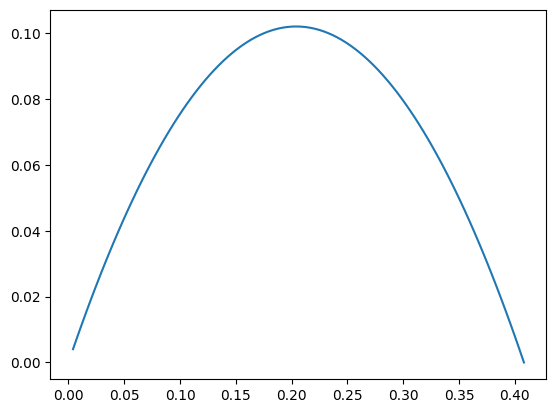

In [ ]:
import casadi as ca
from NumOpt import Opti
import numpy as np

x_hst = []
y_hst = []
vx_hst = []
vy_hst = []


def f(states, dt):
    vx0 = states[0, 0]
    vy0 = states[1, 0]
    x0 = states[2, 0]
    y0 = states[3, 0]

    vx1 = vx0
    vy1 = vy0 - 9.8 * dt
    x1 = x0 + (vx0 + vx1) / 2.0 * dt
    y1 = y0 + (vy0 + vy1) / 2.0 * dt
    new_states = ca.vertcat(vx1, vy1, x1, y1)
    return new_states


def gen_cafunc():
    # x0=ca.GenSX_sym("x")
    # y0=ca.GenSX_sym("y")
    # vx0=ca.GenSX_sym("vx")
    # vy0=ca.GenSX_sym("vy")
    states = ca.GenSX_sym("states", 4, 1)
    dt0 = ca.GenSX_sym("dt")
    new_states = f(states, dt0)
    F = ca.Function("F", [states, dt0], [new_states])
    return F


F = gen_cafunc()
F_fold = F.fold(100)
F_cum = F.mapaccum(100)


opti = Opti()
theta = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=90.0)
dt = opti.variable(init_guess=0.01, lower_bound=0.0)

x0 = 0.0
y0 = 0.0
V = 2.0
vx0 = V * ca.cos(theta / 180.0 * ca.pi)
vy0 = V * ca.sin(theta / 180.0 * ca.pi)
states0 = ca.vertcat(vx0, vy0, x0, y0)

# statesf=F_fold(states0,dt)
statesf = F_cum(states0, dt)
# print(statesf)
opti.subject_to([statesf[3, -1] == 0.0])
opti.maximize(statesf[2, -1])
opti.solver()
sol = opti.solve()
print(sol(theta))
# print(sol(dt))
# print(sol(statesf))

import matplotlib.pyplot as plt

fig = plt.figure(0)
ax = fig.add_subplot(111)
ax.plot(sol(statesf)[2, :], sol(statesf)[3, :])
plt.show()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -4.0373323e+00 9.31e-01 1.48e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

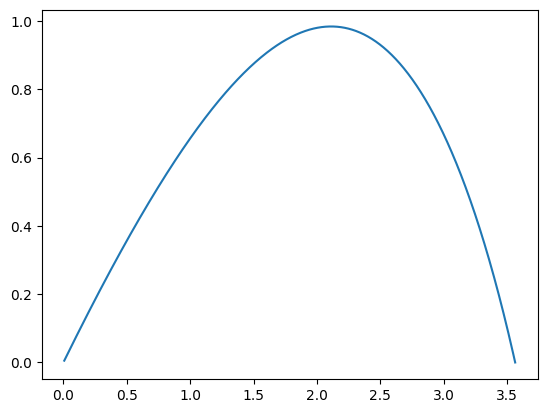

In [ ]:
import casadi as ca
from NumOpt import Opti
import numpy as np

x_hst = []
y_hst = []
vx_hst = []
vy_hst = []


def ode(states, cd, dt):
    vx0 = states[0, 0]
    vy0 = states[1, 0]
    x0 = states[2, 0]
    y0 = states[3, 0]

    v0 = ca.sqrt(vx0**2 + vy0**2)
    sin_theta = vy0 / v0
    cos_theta = vx0 / v0

    drag = 0.5 * 1.225 * v0**2 * cd
    dragx = drag * cos_theta
    dragy = drag * sin_theta

    vx1 = vx0 - dragx * dt
    vy1 = vy0 - (9.8 + dragy) * dt
    x1 = x0 + (vx0 + vx1) / 2.0 * dt
    y1 = y0 + (vy0 + vy1) / 2.0 * dt
    new_states = ca.vertcat(vx1, vy1, x1, y1)
    return new_states


def gen_cafunc():
    # x0=ca.GenSX_sym("x")
    # y0=ca.GenSX_sym("y")
    # vx0=ca.GenSX_sym("vx")
    # vy0=ca.GenSX_sym("vy")
    states = ca.GenSX_sym("states", 4, 1)
    dt = ca.GenSX_sym("dt")
    cd = ca.GenSX_sym("cd")
    new_states = ode(states, cd, dt)
    F = ca.Function("F", [states, cd, dt], [new_states])
    return F


N = 1000
F = gen_cafunc()
F_fold = F.fold(N)
F_cum = F.mapaccum(N)

opti = Opti()
theta = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=90.0)
tf = opti.variable(init_guess=1.0, lower_bound=0.0)
dt = tf / (N - 1)

x0 = 0.0
y0 = 0.0
V = 10.0
cd = 0.5
vx0 = V * np.cos(theta / 180.0 * np.pi)
vy0 = V * np.sin(theta / 180.0 * np.pi)
states0 = ca.vertcat(vx0, vy0, x0, y0)

# statesf=F_fold(states0,dt)
statesf = F_cum(states0, cd, dt)
# print(statesf)
opti.subject_to(
    [
        statesf[3, -1] == 0.0,
    ]
)
opti.maximize(statesf[2, -1])
opti.solver()
try:
    sol = opti.solve()
except:
    sol = opti.debug.value
print(sol(theta))
print(sol(dt))
print(sol(statesf)[:, -1])
print(sol(vx0), sol(vy0))
print(sol(statesf)[:, 0])

import matplotlib.pyplot as plt

fig = plt.figure(0)
ax = fig.add_subplot(111)
ax.plot(sol(statesf)[2, :], sol(statesf)[3, :])
plt.show()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -4.0373323e+00 9.31e-01 1.48e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

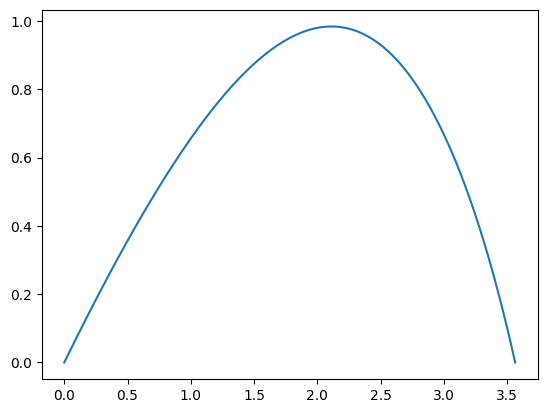

In [ ]:
import casadi as ca
from NumOpt import Opti
import numpy as np

opti = Opti()
theta = opti.variable(init_guess=30.0, lower_bound=0.0, upper_bound=90.0)
tf = opti.variable(init_guess=1.0, lower_bound=0.0)
N = 1000
dt = tf / (N - 1)

vx_hst = []
vy_hst = []
x_hst = []
y_hst = []

x = 0.0
y = 0.0
V = 10.0
vx = V * np.cos(theta / 180.0 * np.pi)
vy = V * np.sin(theta / 180.0 * np.pi)
cd = 0.5

vx_hst.append(vx)
vy_hst.append(vy)
x_hst.append(x)
y_hst.append(y)

for i in range(N):
    v = ca.sqrt(vx**2 + vy**2)
    cos_theta = vx / v
    sin_theta = vy / v
    drag = 0.5 * 1.225 * v**2 * cd
    dragx = drag * cos_theta
    dragy = drag * sin_theta

    vx1 = vx - dragx * dt
    vy1 = vy - 9.8 * dt - dragy * dt
    x1 = x + (vx + vx1) / 2.0 * dt
    y1 = y + (vy + vy1) / 2.0 * dt

    vx_hst.append(vx1)
    vy_hst.append(vy1)
    x_hst.append(x1)
    y_hst.append(y1)

    vx = vx1
    vy = vy1
    x = x1
    y = y1

vx_hst = ca.hcat(vx_hst)
vy_hst = ca.hcat(vy_hst)
x_hst = ca.hcat(x_hst)
y_hst = ca.hcat(y_hst)

opti.subject_to([y_hst[0, -1] == 0.0])

opti.maximize(x_hst[0, -1])
opti.solver()
sol = opti.solve()
print(sol(theta))

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(sol(x_hst), sol(y_hst))
plt.show()

In [ ]:
import numpy as np
import casadi as ca
import jax.numpy as jnp
import jax

In [ ]:
def func(x):
    ret = x * np.sin(x) + x
    return ret


N = int(1e7)
for i in range(N):
    ret = func(i)
print(ret)

19906644.486696616


In [ ]:
def gen_func():
    def _fun(x):
        ret = x * ca.sin(x) + x
        return ret

    x = ca.GenSX_sym("x")
    ret = _fun(x)
    func = ca.Function("func", [x], [ret])
    return func


func = gen_func()
N = int(1e7)
for i in range(N):
    ret = func(i)
print(ret)

1.99066e+07


In [ ]:
@jax.jit()
def func(x):
    ret = x * jnp.sin(x) + x
    return ret


N = int(1e7)
for i in range(N):
    ret = func(i)
print(ret)

1.9906644e+07


In [ ]:
def func(N):
    def _func(i, x):
        ret = i * jnp.sin(i) + i
        return ret

    return jax.lax.fori_loop(0, N, _func, 0)


N = int(1e7)
print(func(N))

1.9906644e+07


In [ ]:
def f(x, c=5):
    return x**3 - 2 * x - c


from scipy.optimize import elementwise, brent, brenth

res_bracket = elementwise.bracket_root(f, 1, factor=1.2)
res_bracket.success
print(res_bracket.bracket)

# xmin, fval, iter, funcalls  = brent(f,brack=res_bracket.bracket,full_output=True)
# print(xmin,fval)

root = brenth(f, a=res_bracket.bracket[0], b=res_bracket.bracket[1])
print(root)
print(f(root))

(np.float64(2.0), np.float64(2.2))
2.0945514815420427
-3.169020601490047e-12


In [ ]:
import csdl_alpha as csdl
from csdl_alpha.experimental import PySimulator
import modopt as mo
import numpy as np

rec = csdl.Recorder()
rec.start()

cg = np.array([5.75, 0.0, -0.25])
G = 5.5e3 * 9.8

throttle = csdl.Variable(value=np.ones(6) * G / 6.0)
throttle_max = csdl.Variable(value=G / 6.0)

rotor_x = csdl.Variable(value=np.array([3.2, 5.9, 10.06, 3.2, 5.9, 10.06]))
rotor_y = csdl.Variable(value=np.array([2.95, 6.5, 2.0, -2.95, -6.5, -2.0]))

con1 = rotor_y[:3] + rotor_y[3:]
con2 = rotor_y[0] - 2.95
con3 = rotor_y[1] - 6.5
con4 = rotor_y[2] - 2.0

con5 = rotor_x[:3] - rotor_x[3:]
con6 = rotor_x[0]
con7 = rotor_x[1] - 5.9
con8 = rotor_x[2]

con9 = My = csdl.vdot(rotor_x - cg[0], throttle)
con10 = Mx = csdl.vdot(rotor_y, throttle)

con11 = totot_T = csdl.sum(throttle)
con12 = throttle_max - throttle

idx = 1
con13 = throttle[idx]

throttle.set_as_design_variable(lower=0.0)
throttle_max.set_as_design_variable(lower=0.0)
rotor_x.set_as_design_variable()
rotor_y.set_as_design_variable()

con1.set_as_constraint(equals=0.0)
con2.set_as_constraint(equals=0.0)
con3.set_as_constraint(equals=0.0)
con4.set_as_constraint(equals=0.0)
con5.set_as_constraint(equals=0.0)
con6.set_as_constraint(lower=3.0, upper=3.5)
con7.set_as_constraint(equals=0.0)
con8.set_as_constraint(lower=10.0, upper=11.0)
con9.set_as_constraint(equals=0.0)
con10.set_as_constraint(equals=0.0)
con11.set_as_constraint(equals=G)
con12.set_as_constraint(lower=0.0)
con13.set_as_constraint(equals=0.0)

throttle_max.set_as_objective()

rec.stop()


sim = PySimulator(recorder=rec)
prob = mo.CSDLAlphaProblem(problem_name="propeller", simulator=sim)

# optimizer=mo.IPOPT(problem=prob,solver_options={"max_iter":100,"tol":1e-6})
optimizer = mo.SLSQP(problem=prob, solver_options={"maxiter": 100, "ftol": 1e-6})
sol = optimizer.solve()
optimizer.print_results()

print(throttle.value)
print(throttle.value / G * 6)

In [ ]:
import csdl_alpha as csdl


class UDP(csdl.CustomExplicitOperation):
    def __init__(self):
        super().__init__()

    def evaluate(self, x):
        self.declare_input("x", variable=x)
        z = self.create_output("z", shape=(1,))

        self.declare_derivative_parameters(of="z", wrt="x", method="fd")

        return z

    def compute(self, inputs, outputs):
        x = inputs["x"]
        outputs["z"] = x**2 - 10

    # def compute_derivatives(self, inputs, outputs, derivatives):
    #     # x=inputs["x"]
    #     # derivatives["z","x"]=2*x
    #     pass


rec = csdl.Recorder(inline=True)
rec.start()

x = csdl.ImplicitVariable(value=5)

udp = UDP()
z = udp.evaluate(x)
# z=x**2-1

solver = csdl.nonlinear_solvers.BracketedSearch()
solver.add_state(x, z, bracket=(0, 2))

solver.run()

rec.stop()


print(x.value)
print(z.value)

KeyboardInterrupt: 

In [ ]:
import casadi as ca
import jax.numpy as jnp


class Bspline:
    def __init__(self, cpts: np.ndarray, degree=3):
        self.cpts = cpts
        self.degree = degree
        self.segments = self.cpts.shape[0] - self.degree
        if self.segments < 1:
            raise ValueError("the contrl points number must be > degree")
        self.knots = self.quasi_uniform_knots()

    def quasi_uniform_knots(self):
        middle = np.linspace(0, 1, self.segments + 1)
        start = np.zeros(self.degree, dtype="f8")
        end = np.ones(self.degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    @staticmethod
    def deBoor(u, i, k, knots):
        if k == 0:
            flag = ca.logic_and(u >= knots[i], u < knots[i + 1])
            return ca.if_else(flag, 1.0, 0.0)
        else:
            term1 = term2 = 0.0
            delta_1 = knots[i + k] - knots[i]
            if delta_1 != 0.0:
                term1 = (u - knots[i]) / (delta_1) * Bspline.deBoor(u, i, k - 1, knots)

            delta_2 = knots[i + k + 1] - knots[i + 1]
            if delta_2 != 0.0:
                term2 = (knots[i + k + 1] - u) / delta_2 * Bspline.deBoor(u, i + 1, k - 1, knots)
            return term1 + term2


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [1.0, 0.0]])
sp = Bspline(cpts=cpts)
sp.deBoor(u=np.array([0.0, 0.5, 1.0]), i=1, k=3, knots=sp.knots)

DM([0, 0.375, 0])

[0.6625 0.6375]
0.637499999907903
[[ 1.575  0.525]
 [ 1.896 -0.048]]
[[ 2.7  -5.1 ]
 [ 3.72 -6.36]]


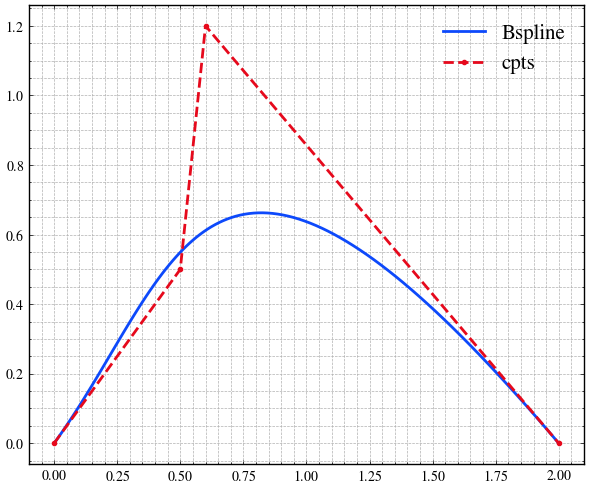

In [ ]:
from scipy.interpolate import BSpline, interp1d
import matplotlib.pyplot as plt
import scienceplots


class Bspline:
    def __init__(self, cpts: np.ndarray, degree=3, fast_lookup=False):
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots()
        self._sp = BSpline.construct_fast(t=self.knots, c=self.cpts, k=self.degree, extrapolate=True)
        self._sp_d1 = self._sp.derivative(1)
        self._sp_d2 = self._sp.derivative(2)
        if fast_lookup:
            self.look_table = self.gen_look_table()
            self.look_interp = interp1d(x=self.look_table[:, 0], y=self.look_table[:, 1], kind="cubic")

    def quasi_uniform_knots(self):
        middle = np.linspace(0, 1, self.cpts.shape[0] - self.degree + 1)
        start = np.zeros(self.degree, dtype="f8")
        end = np.ones(self.degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    def __call__(self, u):
        return self._sp(u)

    def d1(self, u):
        return self._sp_d1(u)

    def d2(self, u):
        return self._sp_d2(u)

    def gen_look_table(self):
        u = np.linspace(0, 1, 200)
        xy = self._sp(u)
        return xy

    def get_y_by_lookup(self, x):
        return self.look_interp(x)

    # def get_y_from_x(self,x):
    #     num_x=x.shape[0]

    #     u0=np.ones(num_x)*0.5
    #     ul=np.zeros(num_x)
    #     uu=np.ones(num_x)

    #     xy=BSpline()


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
sp = Bspline(cpts=cpts, degree=3, fast_lookup=True)
u = np.linspace(0, 1, 100)
xy = sp(u)
print(sp(0.5))
print(sp.get_y_by_lookup(0.6625))
print(sp.d1([0.5, 0.6]))
print(sp.d2([0.5, 0.6]))

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy[:, 0], xy[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()

[1.575, 0.525]
-5.1
[0.6625, 0.6375]
[1.5, 0.387214]


func failed: .../casadi/interfaces/sundials/kinsol_interface.cpp:317: Assertion "!isnan(f_data[k])" failed:
Nonzero 0 is not-a-number



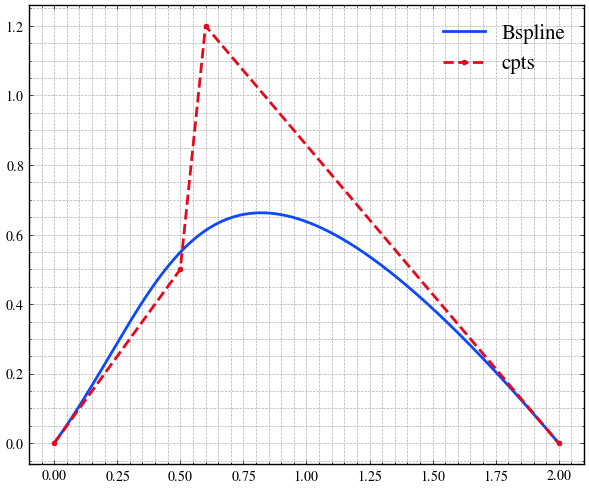

In [ ]:
import casadi as ca
from scipy.interpolate import BSpline
import numpy as np
import matplotlib.pyplot as plt
import scienceplots


class BsplineCasadi(ca.Callback):
    def __init__(self, name, cpts: np.ndarray, degree=3, extrapolate=False, opts={"enable_fd": False}):
        ca.Callback.__init__(self)
        self.construct(name, opts)
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots()
        self._sp = BSpline.construct_fast(t=self.knots, c=self.cpts, k=self.degree, extrapolate=extrapolate)
        self._sp_d1 = self._sp.derivative(1)
        self._sp_d2 = self._sp.derivative(2)

        self.get_xy_from_x = self.gen_get_y_from_x()

    def quasi_uniform_knots(self):
        middle = np.linspace(0, 1, self.cpts.shape[0] - self.degree + 1)
        start = np.zeros(self.degree, dtype="f8")
        end = np.ones(self.degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    def get_n_in(self):
        return 1

    def get_sparsity_in(self, i):
        return ca.Sparsity.dense(1, 1)

    def get_n_out(self):
        return 1

    def get_sparsity_out(self, i):
        return ca.Sparsity.dense(2, 1)

    def eval(self, args):
        u = args[0]
        u = u.toarray().ravel()
        xy = self._sp(u).reshape((-1, 1))
        return [xy]

    def has_jacobian(self):
        return True

    def get_jacobian(self, name, inames, onames, opts):
        class JacFun(ca.Callback):
            def __init__(self_jac, opts={"enable_fd": False}):
                ca.Callback.__init__(self_jac)
                self_jac.construct(name, opts)

            def get_n_in(self_jac):
                return 2

            def get_n_out(self_jac):
                return 1

            def get_sparsity_in(self_jac, i):
                if i == 0:
                    return ca.Sparsity.dense(1, 1)
                elif i == 1:
                    return ca.Sparsity.dense(2, 1)

            def get_sparsity_out(self_jac, i):
                return ca.Sparsity.dense(2, 1)

            def eval(self_jac, args):
                u = args[0]
                u = u.toarray().ravel()
                jac = self._sp_d1(u).reshape((-1, 1))
                return [jac]

            def has_jacobian(self_jac):
                return True

            def get_jacobian(self_jac, name, inames, onames, opts):
                class HessFun(ca.Callback):
                    def __init__(self_hess, opts={}):
                        ca.Callback.__init__(self_hess)
                        self_hess.construct(name, opts)

                    def get_n_in(self_hess):
                        return 3

                    def get_n_out(self_hess):
                        return 2

                    def get_sparsity_in(self_hess, i):
                        if i == 0:
                            return ca.Sparsity.dense(1, 1)
                        elif i == 1:
                            return ca.Sparsity.dense(2, 1)
                        elif i == 2:
                            return ca.Sparsity.dense(2, 1)

                    def get_sparsity_out(self_hess, i):
                        if i == 0:
                            return ca.Sparsity.dense(2, 1)
                        elif i == 1:
                            return ca.Sparsity.dense(2, 2)

                    def eval(self_hess, args):
                        u = args[0]
                        u = u.toarray().ravel()
                        hess_u = self._sp_d2(u).reshape((-1, 1))
                        hess_xy = ca.GenDM_zeros(2, 2)
                        return [hess_u, hess_xy]

                self_jac.jac_callback = HessFun()
                return self_jac.jac_callback

        self.jac_callback = JacFun()
        return self.jac_callback

    def gen_get_y_from_x(self):
        x = ca.SX.sym("x")
        u_star = self.__get_y_from_x()(0.5, x)
        xy_star = self(u_star)

        func = ca.Function("get_y_from_x", [x], [xy_star])
        return func

    def __get_y_from_x(self):
        u = ca.SX.sym("u")
        x = ca.SX.sym("x")
        xy = self(u)
        F1 = xy[0, 0] - x

        g = ca.Function("g", [u, x], [F1])
        sol = ca.rootfinder("G", "kinsol", g)
        return sol


cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
sp = BsplineCasadi("sp", cpts=cpts, degree=3)
# print(sp(0.5))

u = np.linspace(0, 1, 1000)
dumpy_x = ca.SX.sym("x")
sp_func = ca.Function("sp_func", [dumpy_x], [sp(dumpy_x)])
sp_func_jac = ca.Function("sp_func", [dumpy_x], [ca.jacobian(sp(dumpy_x), dumpy_x)])
sp_func_hess = ca.Function("sp_func", [dumpy_x], [ca.hessian(sp(dumpy_x)[1, 0], dumpy_x)[0]])

print(sp_func_jac(0.5))
print(sp_func_hess(0.5))
sp_func_mpi = sp_func.map(u.shape[0])

xy_list = sp_func_mpi(u).T


# from NumOpt import Opti
# opti=Opti()
# u=opti.variable(init_guess=0.5,lower_bound=0.0,upper_bound=1.0)
# xy=sp(u).T
# opti.subject_to([
#     xy[0,0]==0.6625
# ])
# opti.ipopt_solver()
# sol=opti.solve()
# print(sol(xy))

print(sp.get_xy_from_x(0.6625))
print(sp.get_xy_from_x(1.5))

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy_list[:, 0], xy_list[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()

In [ ]:
import casadi as ca

x = ca.SX.sym("x", 1, 1)
y1 = x
y2 = 2 * x**2
# y=ca.veccat(y1,y2)
y = ca.veccat(y1, y2)
func = ca.Function("func", [x], [y])
func_jac = ca.Function("func_jac", [x], [ca.jacobian(func(x), x)])
func_hess = ca.Function("func_hess", [x], [ca.hessian(func(x)[1, 0], x)[0]])

func(2).shape, func_jac(2).shape, func_hess(2)

((2, 1), (2, 1), DM(4))

In [ ]:
import casadi as ca
import aerosandbox.numpy as anp

anp.prod
x = ca.SX.sym("x", 2, 1)
p = ca.SX.sym("p", 1, 1)

F1 = ca.sum(x) - p
F2 = x[0, 0] * x[1, 0] - p
F = ca.vertcat(F1, F2)
g = ca.Function("g", [x, p], [F])

G = ca.rootfinder("G", "kinsol", g)
sol = G([0.5, 2.0], 4)
print(sol)

[2, 2]


In [ ]:
import casadi as ca

# 1. 定义 F(z,p) = 0
z = ca.SX.sym("z")  # 未知量，必须放第一个输入
p = ca.SX.sym("p")  # 参数，放第二个输入，可以是向量
F = z**2 - p  # 等式方程，写成 残差 = 0 的形式

F_func = ca.Function("F", [z, p], [F])

# 2. 造求解器
rf = ca.rootfinder("rf", "kinsol", F_func)

# 3. 求解，给 初值z0, 参数p
z_sol = rf(1.0, 16)  # 解 z^2=2，初值1 -> 1.4142...
print(z_sol)

-4


In [ ]:
import casadi as ca

x = ca.SX.sym("x")
thresholds = [0.5, 2.0]
idx = ca.sum(x > thresholds)

f0 = ca.DM.ones(1, 1)
f1 = -x + 1
f2 = 2 * x - 2

cond = ca.conditional(idx, [f0, f1], f2)
func_cond = ca.Function("func_cond", [x], [cond])

func_cond(3)

DM(4)

In [ ]:
import casadi as ca
import jax
import jax.numpy as jnp


def gen_f():
    x = ca.SX.sym("x")
    y = ca.sin(x)
    f = ca.Function("f", [x], [y])
    return f


f = gen_f()
N = 1000000
x = 0.74

# for _ in range(N):
#     x=f(x)
# print(x)

f_fold = gen_f().fold(N)
print(float(f_fold(x)))

dumpy_x = ca.SX.sym("dumpy_x")
f_fold_grad = ca.Function("f_fold_grad", [dumpy_x], [ca.gradient(f_fold(dumpy_x), dumpy_x)])
print(float(f_fold_grad(x)))

0.0017320397292494738
1.1302855502868415e-08


In [ ]:
import casadi as ca
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)


@jax.jit
def f(i, val):
    return jnp.sin(val)


@jax.jit
def f_mpi(x):
    return jax.lax.fori_loop(0, N, f, x)


f_mpi_grad = jax.jit(jax.grad(f_mpi))

N = 1000000
x = 0.74

# for _ in range(N):
#     x=f(_,x)
# print(x)

print(f_mpi(x=x))
print(f_mpi_grad(x))

0.001732039729249476
1.1302855502868393e-08


[0.38751725 0.4589476  0.52332931]
[[0.1397 0.1539]
 [0.6625 0.6375]
 [0.8352 0.6624]]


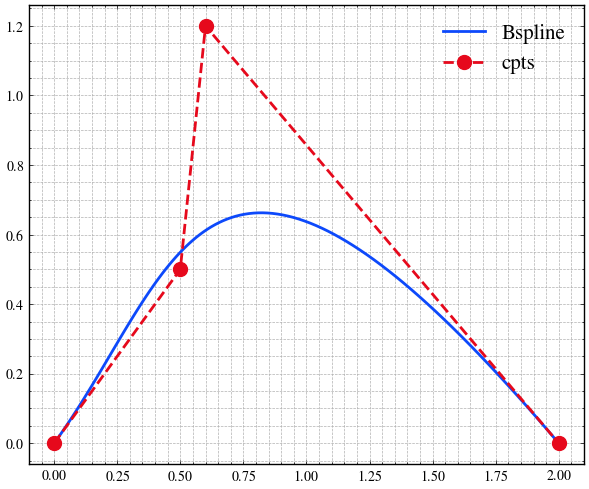

In [17]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
import scienceplots 
from NumOpt import Opti 
import aerosandbox as asb 

def cosspace(start: float = 0.0, stop: float = 1.0, num: int = 50):
    mean = (stop + start) / 2
    amp = (stop - start) / 2
    ones = 0 * start + 1
    spaced_array = mean + amp * np.cos(np.linspace(np.pi * ones, 0 * ones, num))

    # Fix the endpoints, which might not be exactly right due to floating-point error.
    spaced_array[0] = start
    spaced_array[-1] = stop

    return spaced_array

class BsplineCurve:
    def __init__(self, cpts: np.ndarray, degree=3):
        self.cpts = cpts
        self.degree = degree
        self.knots = self.quasi_uniform_knots(self.cpts.shape[0], self.degree)
        self.setup()

    def setup(self):
        u = ca.MX.sym("u")
        sp = ca.bspline(u, self.cpts, [self.knots], [self.degree], 1, {})
        self.spx = ca.Function("spx", [u], [sp])


    @staticmethod
    def quasi_uniform_knots(ncpts, degree):
        middle = np.linspace(0, 1, ncpts - degree + 1)
        start = np.zeros(degree, dtype="f8")
        end = np.ones(degree, dtype="f8")
        knots = np.hstack([start, middle, end])
        return knots

    def get_xy_from_u(self, u, to_numpy=True):
        xy = self.spx(u)
        if to_numpy:
            xy = xy.toarray()
        return xy 

    def get_xy_from_x(self,x,to_numpy=True):
        u=ca.MX.sym("u",x.shape[0])
        xy=self.get_xy_from_u(u,False)
        residual=xy[:,0]-x 

        sol=ca.rootfinder("G","kinsol",ca.Function("g",[u],[residual]))(np.ones((x.shape[0],))*0.5)
        if to_numpy:
            sol=sol.toarray().ravel()
        return sol


class BsplineAirfoil():
    def __init__(self,cptus,cptls,degree):
        self.cptus=cptus 
        self.cptls=cptls 
        self.degree=degree 
        self._spu=BsplineCurve(cpts=self.cptus,degree=self.degree)
        self._spl=BsplineCurve(cpts=self.cptls,degree=self.degree)

    def coordinates(self,u=cosspace(0,1,100),to_numpy=True):
        upper_coords=self._spu.get_xy_from_u(u,to_numpy)
        lower_coords=self._spl.get_xy_from_u(u,to_numpy)
        if to_numpy:
            coords=np.vstack([upper_coords[::-1],lower_coords[1:]])
        else:
            coords=ca.vertcat(upper_coords[::-1,:],lower_coords[1:,:])
        return coords 
    
    def upper_coordinates(self,u=cosspace(0,1,100),to_numpy=True):
        coords=self._spu.get_xy_from_u(u,to_numpy)
        return coords 
    def lower_coordinates(self,u=cosspace(0,1,100),to_numpy=True):
        coords=self._spl.get_xy_from_u(u,to_numpy)
        return coords 
    
    @staticmethod
    def fit(upper_coords,lower_coords,TE=None,ncptus=9,ncptls=9,degree=3):
        opti=Opti()

        cptus_x=np.zeros((ncptus,))
        cptus_x[1:]=cosspace(0,1,ncptus-1)

        cptls_x=np.zeros((ncptls,))
        cptls_x[1:]=cosspace(0,1,ncptls-1)

        cptus_y=opti.variable(init_guess=0.06,n_vars=ncptus-2)
        cptls_y=opti.variable(init_guess=0.06,n_vars=ncptls-2)

        tu=opti.variable(init_guess=0.5,n_vars=upper_coords.shape[0],lower_bound=0.0,upper_bound=1.0)
        tl=opti.variable(init_guess=0.5,n_vars=lower_coords.shape[0],lower_bound=0.0,upper_bound=1.0)


        if TE:
            cptus_y=ca.horzcat([0.0],cptus_y,[TE/2.0])
            cptls_y=ca.horzcat([0.0],cptls_y,[-TE/2.0])
        else:
            cptus_y=ca.horzcat([0.0],cptus_y,[upper_coords[-1,1]])
            cptls_y=ca.horzcat([0.0],cptls_y,[lower_coords[-1,1]])

        # cptus=ca.vertcat(cptus_x,cptus_y)
        # cptls=ca.vertcat(cptls_x,cptls_y)

        spu_x=ca.bspline(tu,cptus_x,[BsplineCurve.quasi_uniform_knots(cptus_x.shape[0])],[degree],1,{})
        spu_y=ca.bspline(tu,cptus_y,[BsplineCurve.quasi_uniform_knots(cptus_y.shape[0])],[degree],1,{})

        spl_x=ca.bspline(tl,cptls_x,[BsplineCurve.quasi_uniform_knots(cptls_x.shape[0])],[degree],1,{})
        spl_y=ca.bspline(tl,cptls_y,[BsplineCurve.quasi_uniform_knots(cptls_y.shape[0])],[degree],1,{})

        dist_u=(upper_coords[:,0]-spu_x)**2+(upper_coords[:,1]-spu_y)**2
        dist_l=(lower_coords[:,0]-spl_x)**2+(lower_coords[:,1]-spl_y)**2

        dist=ca.sum(dist_u)+ca.sum(dist_l)

        opti.minimize(dist)
        opti.ipopt_solver()
        sol=opti.solve()






cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
sp = BsplineCurve(cpts=cpts, degree=3)
u = np.linspace(0, 1, 100)
xy = sp.get_xy_from_u(u)
print(sp.get_xy_from_x(np.array([0.5,0.6,0.7])))
print(sp.get_xy_from_u([0.1,0.5,0.6]))


# af_init=asb.Airfoil("n63415")
# BsplineAirfoil.fit(upper_coords=af_init.upper_coordinates(),lower_coords=af_init.lower_coordinates(),TE=None,ncptus=9,ncptls=9,degree=3)



with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))

        ax = fig.add_subplot(111)
        ax.plot(xy[:, 0], xy[:, 1], label="Bspline")
        ax.plot(cpts[:, 0], cpts[:, 1], "--o", markersize=10, label="cpts")

        ax.legend(fontsize=15)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2)
        plt.show()




In [39]:
import casadi as ca 
import numpy as np 
from NumOpt import Opti 

def quasi_uniform_knots(ncpts, degree):
    middle = np.linspace(0, 1, ncpts - degree + 1)
    start = np.zeros(degree, dtype="f8")
    end = np.ones(degree, dtype="f8")
    knots = np.hstack([start, middle, end])
    return knots

u=ca.MX.sym("u")
# cpts = ca.MX.sym("cpts",4,2)
cpts = np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
knots=quasi_uniform_knots(ncpts=cpts.shape[0],degree=3)

sp=ca.bspline(u,cpts.T,[knots],[3],2,{})

sp=ca.Function("sp",[u],[sp])
# sp(ca.DM([[0.1,0.5,0.6,0.8]]),np.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])).T
sp(ca.DM([[0.1,0.5,0.6,0.8,0.9]])).T

DM(
[[0.1397, 0.1539], 
 [0.6625, 0.6375], 
 [0.8352, 0.6624], 
 [1.3024, 0.5088], 
 [1.6173, 0.3051]])

In [42]:

import casadi as ca
import numpy as np

v = ca.MX.sym("v",5)
p0 = [-1,0,0.2,1,1.3,2,2.5,3,3.5,4,4.5]
p = ca.MX.sym("p",len(p0))


f = ca.Function("f",[v,p],[ca.low(v, p)])

inputs = [[0,1,2,3,4],p0]

f(*inputs)

DM([0, 0, 0, 1, 1, 2, 2, 3, 3, 3, 3])

In [43]:
import jax 
import jax.numpy as jnp 
from functools import partial

jax.config.update("jax_enable_x64",True)

def quasi_uniform_knots(ncpts, degree):
    middle = jnp.linspace(0, 1, ncpts - degree + 1)
    start = jnp.zeros(degree, dtype="f8")
    end = jnp.ones(degree, dtype="f8")
    knots = jnp.hstack([start, middle, end])
    return knots

@jax.jit
def find_span(u,knots,degree,ncpts):
    s=jnp.searchsorted(knots,u,side="right")-1
    s = jnp.clip(s, degree, ncpts - 1)
    return s

@partial(jax.jit, static_argnames=("degree",))
def de_boor(u, cpts, knots, degree):
    """
    de Boor algorithm, fully JIT-compatible.

    u : scalar
    P : (n_ctrl, dim)
    knots : (n_knots,)
    degree : int (static)

    Returns: (dim,)
    """
    p = degree

    s = find_span(u, knots, p,cpts.shape[0])

    # 取局部控制点 d[j] = P[s-p+j], j=0..p
    idx0 = s - p
    idxs = idx0 + jnp.arange(p + 1, dtype=jnp.int32)
    d = cpts[idxs, :]   # (p+1, dim)

    for r in range(1, p + 1):
        for j in range(p, r - 1, -1):
            i = s - p + j
            denom = knots[i + p - r + 1] - knots[i]
            alpha = jnp.where(
                jnp.abs(denom) < 1e-14,
                0.0,
                (u - knots[i]) / denom,
            )
            dj = (1.0 - alpha) * d[j - 1] + alpha * d[j]
            d = d.at[j].set(dj)

    return d[p]

cpts = jnp.array([[0.0, 0.0], [0.5, 0.5], [0.6, 1.2], [2.0, 0.0]])
degree=3 

knots=quasi_uniform_knots(cpts.shape[0],degree)
print(knots)

c=de_boor(0.5,cpts,knots,degree)
print(c)


[0. 0. 0. 0. 1. 1. 1. 1.]
[0.6625 0.6375]


In [38]:
@partial(jax.jit,static_argnames=("degree"))
def func(degree):
    f=jnp.arange(degree,dtype=jnp.int32)
    return f

func(10)

Array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)